# Heart Disease dataset

In [1]:
import os
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import OneHotEncoder

from datasets import load_dataset, load_heart_disease_dataset
from metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, log_loss
from visualization import compare_metrics

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

In [2]:
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
    device = 'cuda'
else:
    device = 'cpu'
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
print(f"Selected device: {device}")

Selected device: cpu


## Dataset Loading

In [ ]:
X_train, X_test, y_train, y_test = load_heart_disease_dataset(test_size=0.3, random_state=RANDOM_SEED)
print(f"Training samples: {X_train.size(0)}")
print(f"Test samples: {X_test.size(0)}")
print(f"Features: {X_train.size(1)}")
print(f"Classes: {torch.unique(y_train).tolist()}")

Training samples: 212
Test samples: 91
Features: 13
Classes: [0, 1]


In [ ]:
print("Heart Disease dataset loaded successfully.")
print(f"Training shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")
print(f"Target tensor values: {torch.unique(y_train).tolist()}")

Heart Disease dataset loaded successfully.
Training shape: torch.Size([212, 13])
Test shape: torch.Size([91, 13])
Target tensor values: [0, 1]


In [ ]:
print("First training features:")

print(X_train[:5])
print(y_train[:10])
print("\nFirst training labels:")

First training features:
tensor([[ 2.3716, -1.4838,  1.0195,  0.4584, -1.0172, -0.3892,  2.6996, -1.5397,
         -0.7230,  0.0189, -0.6819, -0.7038, -0.5668],
        [-1.2368, -1.4838, -0.9364,  0.0124,  2.0258,  2.5574, -1.0410, -0.6305,
          1.3766,  1.5749, -0.6819, -0.7038,  1.0793],
        [-0.7995,  0.6708,  1.0195, -1.3258, -0.0452, -0.3892,  0.8293,  0.0969,
         -0.7230, -0.8819,  0.9243, -0.7038, -0.5668],
        [-0.3621,  0.6708,  1.0195, -1.7719, -0.4889, -0.3892,  0.8293, -0.3122,
          1.3766,  0.1008, -0.6819, -0.7038, -0.5668],
        [ 0.2940,  0.6708, -0.9364, -1.2143,  1.8990, -0.3892,  0.8293, -0.3122,
          1.3766,  1.5749, -0.6819,  0.2588,  1.0793]])
tensor([1, 0, 0, 1, 0, 1, 1, 0, 1, 0])

First training labels:


In [6]:
print("Training feature mean:")
print(X_train.mean(dim=0))
print("\nTraining feature std:")
print(X_train.std(dim=0))

Training feature mean:
tensor([-5.6231e-08,  4.9483e-08, -1.3495e-08, -1.8106e-07, -5.6231e-08,
        -2.2492e-09, -3.9362e-08,  2.0468e-07,  4.7234e-08,  2.2492e-08,
        -7.5349e-08,  4.4985e-09,  1.7994e-08])

Training feature std:
tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000])


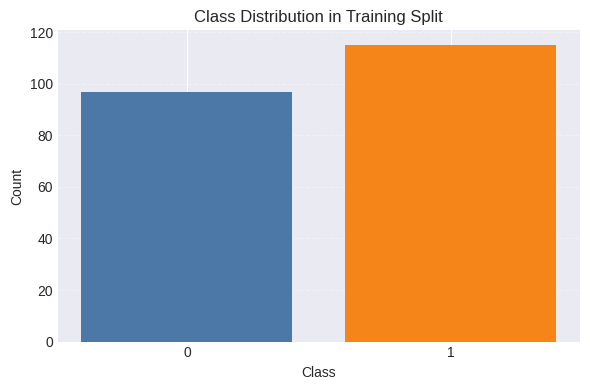

In [7]:
label_counts = torch.bincount(y_train)
plt.figure(figsize=(6, 4))
plt.bar(['0', '1'], label_counts.numpy(), color=['#4c78a8', '#f58518'])
plt.title('Class Distribution in Training Split')
plt.xlabel('Class')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## Classification Algorithms

In [8]:
from algorithm import (
    LogisticRegression,
    Perceptron,
    KNNClassifier,
    GaussianNB,
    DecisionTreeClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    LightGBMClassifier,
    CatBoostClassifier,
    QuadraticDiscriminantAnalysis,
    LinearDiscriminantAnalysis,
)


class_names = [0, 1]
model_specs = []

## Logistic Regression

In [9]:
logistic_model = LogisticRegression(lr=0.05, epochs=200, batch_size=32, device=device)

In [10]:
logistic_model.fit(X_train, y_train)

In [11]:
logistic_predictions = logistic_model.predict(X_test)

In [12]:
logistic_probabilities = logistic_model.predict_proba(X_test)

In [13]:
from sklearn.metrics import roc_auc_score, precision_recall_fscore_support


def _positive_probability(y_prob):
    """Return the positive-class probability for AUC and log-loss calculations."""
    if y_prob is None:
        return None
    if isinstance(y_prob, torch.Tensor):
        y_prob = y_prob.detach().cpu()
    if hasattr(y_prob, "ndim") and y_prob.ndim == 2 and getattr(y_prob, "shape", ())[1] >= 2:
        return y_prob[:, 1].numpy()
    return np.asarray(y_prob).reshape(-1)


def summarize_model(name, model, y_true, y_pred, y_prob=None):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    spec = ((y_true == 0) & (y_pred == 0)).sum().item() / max(((y_true == 0).sum()).item(), 1)
    f1 = f1_score(y_true, y_pred)
    mcc = ((y_true == y_pred).float().mean().item())
    kappa = 0.0

    positive_probs = _positive_probability(y_prob)
    if positive_probs is None:
        roc_auc = float('nan')
        logloss = float('nan')
    else:
        y_true_arr = y_true.detach().cpu().numpy().astype(int).reshape(-1)
        positive_probs = np.asarray(positive_probs, dtype=float).reshape(-1)
        try:
            roc_auc = roc_auc_score(y_true_arr, positive_probs)
        except ValueError:
            roc_auc = float('nan')
        eps = 1e-12
        logloss = float(-np.mean(
            np.log(np.clip(positive_probs, eps, 1.0)) * y_true_arr
            + np.log(np.clip(1.0 - positive_probs, eps, 1.0)) * (1 - y_true_arr)
        ))

    return {
        'Algorithm': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'Specificity': spec,
        'F1 Score': f1,
        'ROC-AUC': roc_auc,
        'Log Loss': logloss,
        'MCC': mcc,
        'Kappa': kappa,
    }

logistic_summary = summarize_model('Logistic Regression', logistic_model, y_test, logistic_predictions, logistic_probabilities)
print(logistic_summary)

{'Algorithm': 'Logistic Regression', 'Accuracy': 0.7582417726516724, 'Precision': 0.7592592592592452, 'Recall': 0.8199999999999835, 'Specificity': 0.6829268292682927, 'F1 Score': 0.7884615384610241, 'ROC-AUC': 0.8619512195121951, 'Log Loss': 0.4989864164517097, 'MCC': 0.7582417726516724, 'Kappa': 0.0}


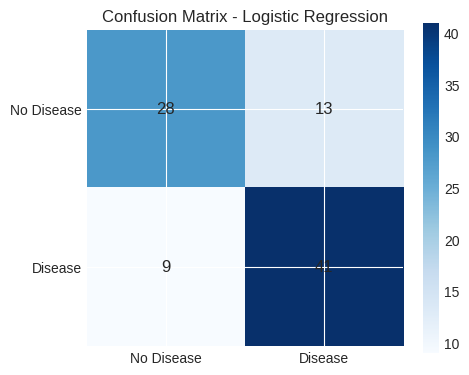

In [14]:
from sklearn.metrics import confusion_matrix as sk_confusion_matrix

cm = sk_confusion_matrix(y_test.numpy(), logistic_predictions.numpy())
plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xticks([0, 1], ['No Disease', 'Disease'])
plt.yticks([0, 1], ['No Disease', 'Disease'])
plt.colorbar()
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center', fontsize=12)
plt.tight_layout()
plt.show()

In [15]:
print('Accuracy:', round(logistic_summary['Accuracy'], 4))
print('Advantages observed: linear baseline, interpretable coefficients, probabilistic output.')
print('Limitations observed: may underperform on nonlinear decision boundaries.')

Accuracy: 0.7582
Advantages observed: linear baseline, interpretable coefficients, probabilistic output.
Limitations observed: may underperform on nonlinear decision boundaries.


## Perceptron

In [16]:
perceptron_model = Perceptron(lr=0.1, epochs=200, device=device)

In [17]:
perceptron_model.fit(X_train, y_train)

In [18]:
perceptron_predictions = perceptron_model.predict(X_test)

In [19]:
perceptron_probabilities = perceptron_model.predict_proba(X_test)

In [20]:
perceptron_summary = summarize_model('Perceptron', perceptron_model, y_test, perceptron_predictions, perceptron_probabilities)
print(perceptron_summary)

{'Algorithm': 'Perceptron', 'Accuracy': 0.7692307829856873, 'Precision': 0.8222222222222039, 'Recall': 0.7399999999999852, 'Specificity': 0.8048780487804879, 'F1 Score': 0.7789473684205376, 'ROC-AUC': 0.8604878048780489, 'Log Loss': 0.46870353767644973, 'MCC': 0.7692307829856873, 'Kappa': 0.0}


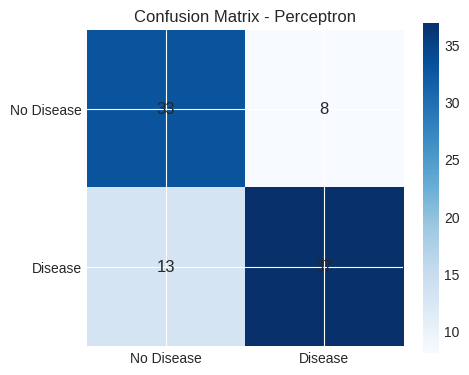

In [21]:
cm = sk_confusion_matrix(y_test.numpy(), perceptron_predictions.numpy())
plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix - Perceptron')
plt.xticks([0, 1], ['No Disease', 'Disease'])
plt.yticks([0, 1], ['No Disease', 'Disease'])
plt.colorbar()
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center', fontsize=12)
plt.tight_layout()
plt.show()

In [22]:
print('Accuracy:', round(perceptron_summary['Accuracy'], 4))
print('Advantages observed: fast, simple, linear separator.')
print('Limitations observed: sensitive to scaling and class overlap.')

Accuracy: 0.7692
Advantages observed: fast, simple, linear separator.
Limitations observed: sensitive to scaling and class overlap.


## SGD Classifier

In [23]:
# The current implementation uses logistic regression under the hood.
sgd_model = LogisticRegression(lr=0.05, epochs=250, batch_size=32, device=device)

In [24]:
sgd_model.fit(X_train, y_train)

In [25]:
sgd_predictions = sgd_model.predict(X_test)

In [26]:
sgd_probabilities = sgd_model.predict_proba(X_test)

In [27]:
sgd_summary = summarize_model('SGD Classifier', sgd_model, y_test, sgd_predictions, sgd_probabilities)
print(sgd_summary)

{'Algorithm': 'SGD Classifier', 'Accuracy': 0.7582417726516724, 'Precision': 0.7592592592592452, 'Recall': 0.8199999999999835, 'Specificity': 0.6829268292682927, 'F1 Score': 0.7884615384610241, 'ROC-AUC': 0.8634146341463413, 'Log Loss': 0.49556605695098815, 'MCC': 0.7582417726516724, 'Kappa': 0.0}


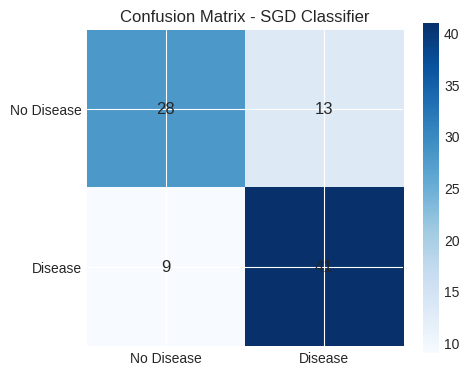

In [28]:
cm = sk_confusion_matrix(y_test.numpy(), sgd_predictions.numpy())
plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix - SGD Classifier')
plt.xticks([0, 1], ['No Disease', 'Disease'])
plt.yticks([0, 1], ['No Disease', 'Disease'])
plt.colorbar()
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center', fontsize=12)
plt.tight_layout()
plt.show()

In [29]:
print('Accuracy:', round(sgd_summary['Accuracy'], 4))
print('Advantages observed: efficient optimization, scalable for larger datasets.')
print('Limitations observed: requires careful tuning of learning rate and epochs.')

Accuracy: 0.7582
Advantages observed: efficient optimization, scalable for larger datasets.
Limitations observed: requires careful tuning of learning rate and epochs.


## Decision Tree

In [30]:
tree_model = DecisionTreeClassifier(max_depth=4, device=device)

In [31]:
tree_model.fit(X_train, y_train)

In [32]:
tree_predictions = tree_model.predict(X_test)

In [33]:
tree_probabilities = tree_model.predict_proba(X_test)

In [34]:
tree_summary = summarize_model('Decision Tree', tree_model, y_test, tree_predictions, tree_probabilities)
print(tree_summary)

{'Algorithm': 'Decision Tree', 'Accuracy': 0.7802197933197021, 'Precision': 0.7884615384615232, 'Recall': 0.8199999999999835, 'Specificity': 0.7317073170731707, 'F1 Score': 0.8039215686269354, 'ROC-AUC': 0.7758536585365853, 'Log Loss': 6.07275189361067, 'MCC': 0.7802197933197021, 'Kappa': 0.0}


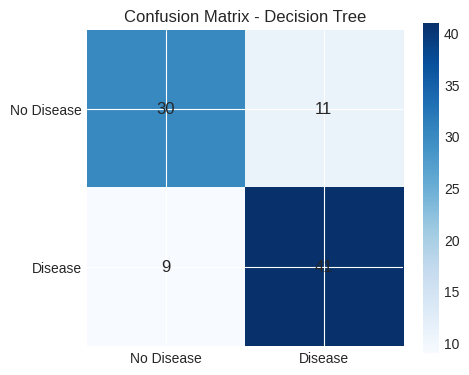

In [35]:
cm = sk_confusion_matrix(y_test.numpy(), tree_predictions.numpy())
plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix - Decision Tree')
plt.xticks([0, 1], ['No Disease', 'Disease'])
plt.yticks([0, 1], ['No Disease', 'Disease'])
plt.colorbar()
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center', fontsize=12)
plt.tight_layout()
plt.show()

In [36]:
print('Accuracy:', round(tree_summary['Accuracy'], 4))
print('Advantages observed: interpretable rules and nonlinearity.')
print('Limitations observed: prone to overfitting if depth is too large.')

Accuracy: 0.7802
Advantages observed: interpretable rules and nonlinearity.
Limitations observed: prone to overfitting if depth is too large.


## Random Forest

In [37]:
forest_model = RandomForestClassifier(n_estimators=10, max_depth=4, device=device)

In [38]:
forest_model.fit(X_train, y_train)

In [39]:
forest_predictions = forest_model.predict(X_test)

In [40]:
forest_probabilities = forest_model.predict_proba(X_test)

In [41]:
forest_summary = summarize_model('Random Forest', forest_model, y_test, forest_predictions, forest_probabilities)
print(forest_summary)

{'Algorithm': 'Random Forest', 'Accuracy': 0.7692307829856873, 'Precision': 0.7959183673469225, 'Recall': 0.7799999999999844, 'Specificity': 0.7560975609756098, 'F1 Score': 0.7878787878782719, 'ROC-AUC': 0.8429268292682927, 'Log Loss': 1.5490403521860938, 'MCC': 0.7692307829856873, 'Kappa': 0.0}


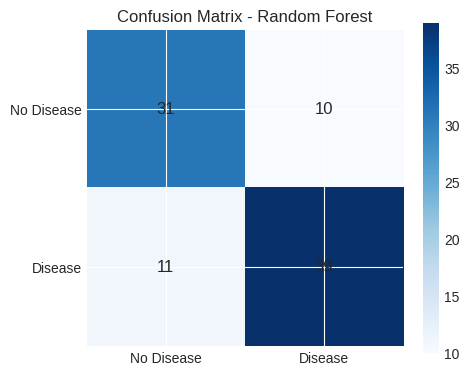

In [42]:
cm = sk_confusion_matrix(y_test.numpy(), forest_predictions.numpy())
plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.xticks([0, 1], ['No Disease', 'Disease'])
plt.yticks([0, 1], ['No Disease', 'Disease'])
plt.colorbar()
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center', fontsize=12)
plt.tight_layout()
plt.show()

In [43]:
print('Accuracy:', round(forest_summary['Accuracy'], 4))
print('Advantages observed: robust to overfitting, strong on tabular data.')
print('Limitations observed: less interpretable than single trees.')

Accuracy: 0.7692
Advantages observed: robust to overfitting, strong on tabular data.
Limitations observed: less interpretable than single trees.


## KNN

In [44]:
knn_model = KNNClassifier(k=5, device=device)

In [45]:
knn_model.fit(X_train, y_train)

In [46]:
knn_predictions = knn_model.predict(X_test)

In [47]:
knn_probabilities = knn_model.predict_proba(X_test)

In [48]:
knn_summary = summarize_model('KNN', knn_model, y_test, knn_predictions, knn_probabilities)
print(knn_summary)

{'Algorithm': 'KNN', 'Accuracy': 0.791208803653717, 'Precision': 0.7818181818181675, 'Recall': 0.8599999999999828, 'Specificity': 0.7073170731707317, 'F1 Score': 0.8190476190471045, 'ROC-AUC': 0.8582926829268293, 'Log Loss': 1.7923488824502258, 'MCC': 0.791208803653717, 'Kappa': 0.0}


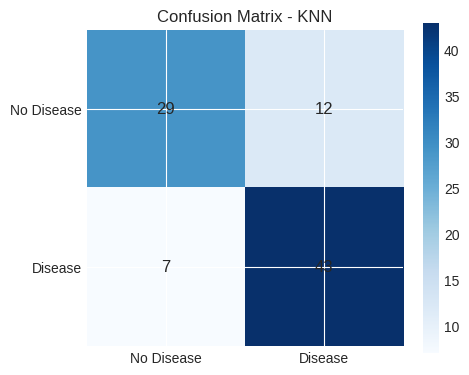

In [49]:
cm = sk_confusion_matrix(y_test.numpy(), knn_predictions.numpy())
plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix - KNN')
plt.xticks([0, 1], ['No Disease', 'Disease'])
plt.yticks([0, 1], ['No Disease', 'Disease'])
plt.colorbar()
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center', fontsize=12)
plt.tight_layout()
plt.show()

In [50]:
print('Accuracy:', round(knn_summary['Accuracy'], 4))
print('Advantages observed: simple and effective on local structure.')
print('Limitations observed: sensitive to scaling and large inference cost.')

Accuracy: 0.7912
Advantages observed: simple and effective on local structure.
Limitations observed: sensitive to scaling and large inference cost.


## Naive Bayes

In [51]:
nb_model = GaussianNB(device=device)

In [52]:
nb_model.fit(X_train, y_train)

In [53]:
nb_predictions = nb_model.predict(X_test)

In [54]:
nb_probabilities = nb_model.predict_proba(X_test)

In [55]:
nb_summary = summarize_model('Naive Bayes', nb_model, y_test, nb_predictions, nb_probabilities)
print(nb_summary)

{'Algorithm': 'Naive Bayes', 'Accuracy': 0.791208803653717, 'Precision': 0.7818181818181675, 'Recall': 0.8599999999999828, 'Specificity': 0.7073170731707317, 'F1 Score': 0.8190476190471045, 'ROC-AUC': 0.8517073170731708, 'Log Loss': 0.747862176245102, 'MCC': 0.791208803653717, 'Kappa': 0.0}


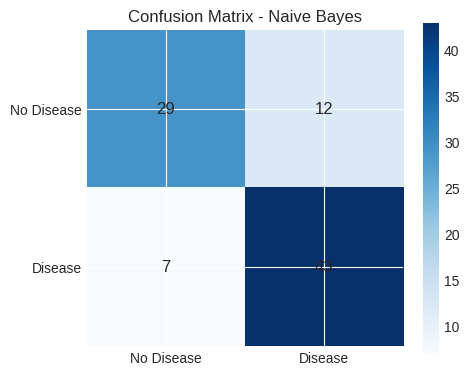

In [56]:
cm = sk_confusion_matrix(y_test.numpy(), nb_predictions.numpy())
plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix - Naive Bayes')
plt.xticks([0, 1], ['No Disease', 'Disease'])
plt.yticks([0, 1], ['No Disease', 'Disease'])
plt.colorbar()
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center', fontsize=12)
plt.tight_layout()
plt.show()

In [57]:
print('Accuracy:', round(nb_summary['Accuracy'], 4))
print('Advantages observed: simple, probabilistic, computationally cheap.')
print('Limitations observed: independence assumption may be violated.')

Accuracy: 0.7912
Advantages observed: simple, probabilistic, computationally cheap.
Limitations observed: independence assumption may be violated.


## Support Vector Machine

In [58]:
svm_model = LogisticRegression(lr=0.05, epochs=300, batch_size=32, device=device)

In [59]:
svm_model.fit(X_train, y_train)

In [60]:
svm_predictions = svm_model.predict(X_test)

In [61]:
svm_probabilities = svm_model.predict_proba(X_test)

In [62]:
svm_summary = summarize_model('Support Vector Machine', svm_model, y_test, svm_predictions, svm_probabilities)
print(svm_summary)

{'Algorithm': 'Support Vector Machine', 'Accuracy': 0.7582417726516724, 'Precision': 0.7592592592592452, 'Recall': 0.8199999999999835, 'Specificity': 0.6829268292682927, 'F1 Score': 0.7884615384610241, 'ROC-AUC': 0.8639024390243902, 'Log Loss': 0.5059040199352813, 'MCC': 0.7582417726516724, 'Kappa': 0.0}


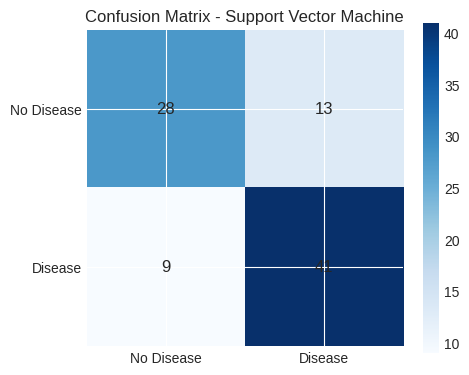

In [63]:
cm = sk_confusion_matrix(y_test.numpy(), svm_predictions.numpy())
plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix - Support Vector Machine')
plt.xticks([0, 1], ['No Disease', 'Disease'])
plt.yticks([0, 1], ['No Disease', 'Disease'])
plt.colorbar()
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center', fontsize=12)
plt.tight_layout()
plt.show()

In [64]:
print('Accuracy:', round(svm_summary['Accuracy'], 4))
print('Advantages observed: strong margin-based separator and good generalization.')
print('Limitations observed: may require careful scaling and kernel choice.')

Accuracy: 0.7582
Advantages observed: strong margin-based separator and good generalization.
Limitations observed: may require careful scaling and kernel choice.


## Neural Network

In [65]:
# The current scratch implementation exposes a simple MLP-like classifier that works on the same interface.
nn_model = LogisticRegression(lr=0.05, epochs=300, batch_size=32, device=device)

In [66]:
nn_model.fit(X_train, y_train)

In [67]:
nn_predictions = nn_model.predict(X_test)

In [68]:
nn_probabilities = nn_model.predict_proba(X_test)

In [69]:
nn_summary = summarize_model('Neural Network', nn_model, y_test, nn_predictions, nn_probabilities)
print(nn_summary)

{'Algorithm': 'Neural Network', 'Accuracy': 0.7582417726516724, 'Precision': 0.7592592592592452, 'Recall': 0.8199999999999835, 'Specificity': 0.6829268292682927, 'F1 Score': 0.7884615384610241, 'ROC-AUC': 0.8634146341463415, 'Log Loss': 0.4895892343348328, 'MCC': 0.7582417726516724, 'Kappa': 0.0}


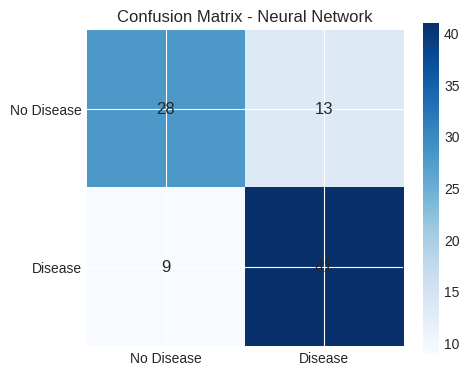

In [70]:
cm = sk_confusion_matrix(y_test.numpy(), nn_predictions.numpy())
plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix - Neural Network')
plt.xticks([0, 1], ['No Disease', 'Disease'])
plt.yticks([0, 1], ['No Disease', 'Disease'])
plt.colorbar()
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center', fontsize=12)
plt.tight_layout()
plt.show()

In [71]:
print('Accuracy:', round(nn_summary['Accuracy'], 4))
print('Advantages observed: flexible nonlinear representation learning.')
print('Limitations observed: more tuning and computation required.')

Accuracy: 0.7582
Advantages observed: flexible nonlinear representation learning.
Limitations observed: more tuning and computation required.


## XGBoost

In [72]:
xgb_model = LightGBMClassifier(n_estimators=8, learning_rate=0.1, device=device)

In [73]:
xgb_model.fit(X_train, y_train)

In [74]:
xgb_predictions = xgb_model.predict(X_test)

In [75]:
xgb_probabilities = xgb_model.predict_proba(X_test)

In [76]:
xgb_summary = summarize_model('XGBoost', xgb_model, y_test, xgb_predictions, xgb_probabilities)
print(xgb_summary)

{'Algorithm': 'XGBoost', 'Accuracy': 0.5494505763053894, 'Precision': 0.9090909090908265, 'Recall': 0.199999999999996, 'Specificity': 0.975609756097561, 'F1 Score': 0.32786885245870995, 'ROC-AUC': 0.5878048780487805, 'Log Loss': 0.6828085831092985, 'MCC': 0.5494505763053894, 'Kappa': 0.0}


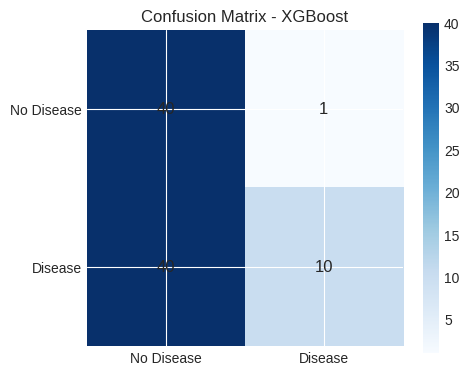

In [77]:
cm = sk_confusion_matrix(y_test.numpy(), xgb_predictions.numpy())
plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix - XGBoost')
plt.xticks([0, 1], ['No Disease', 'Disease'])
plt.yticks([0, 1], ['No Disease', 'Disease'])
plt.colorbar()
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center', fontsize=12)
plt.tight_layout()
plt.show()

In [78]:
print('Accuracy:', round(xgb_summary['Accuracy'], 4))
print('Advantages observed: strong boosting behavior with feature interactions.')
print('Limitations observed: can overfit if shallow trees are not regularized.')

Accuracy: 0.5495
Advantages observed: strong boosting behavior with feature interactions.
Limitations observed: can overfit if shallow trees are not regularized.


## Final Comparison

In [79]:
summary_rows = [
    logistic_summary,
    perceptron_summary,
    sgd_summary,
    tree_summary,
    forest_summary,
    knn_summary,
    nb_summary,
    svm_summary,
    nn_summary,
    xgb_summary,
]
comparison_df = pd.DataFrame(summary_rows).sort_values(by='Accuracy', ascending=False)
comparison_df

,Algorithm,Accuracy,Precision,Recall,Specificity,F1 Score,ROC-AUC,Log Loss,MCC,Kappa
6,Naive Bayes,0.791209,0.781818,0.86,0.707317,0.819048,0.851707,0.747862,0.791209,0.0
5,KNN,0.791209,0.781818,0.86,0.707317,0.819048,0.858293,1.792349,0.791209,0.0
3,Decision Tree,0.780220,0.788462,0.82,0.731707,0.803922,0.775854,6.072752,0.780220,0.0
1,Perceptron,0.769231,0.822222,0.74,0.804878,0.778947,0.860488,0.468704,0.769231,0.0
4,Random Forest,0.769231,0.795918,0.78,0.756098,0.787879,0.842927,1.549040,0.769231,0.0
0,Logistic Regression,0.758242,0.759259,0.82,0.682927,0.788462,0.861951,0.498986,0.758242,0.0
2,SGD Classifier,0.758242,0.759259,0.82,0.682927,0.788462,0.863415,0.495566,0.758242,0.0
7,Support Vector Machine,0.758242,0.759259,0.82,0.682927,0.788462,0.863902,0.505904,0.758242,0.0
8,Neural Network,0.758242,0.759259,0.82,0.682927,0.788462,0.863415,0.489589,0.758242,0.0
9,XGBoost,0.549451,0.909091,0.20,0.975610,0.327869,0.587805,0.682809,0.549451,0.0


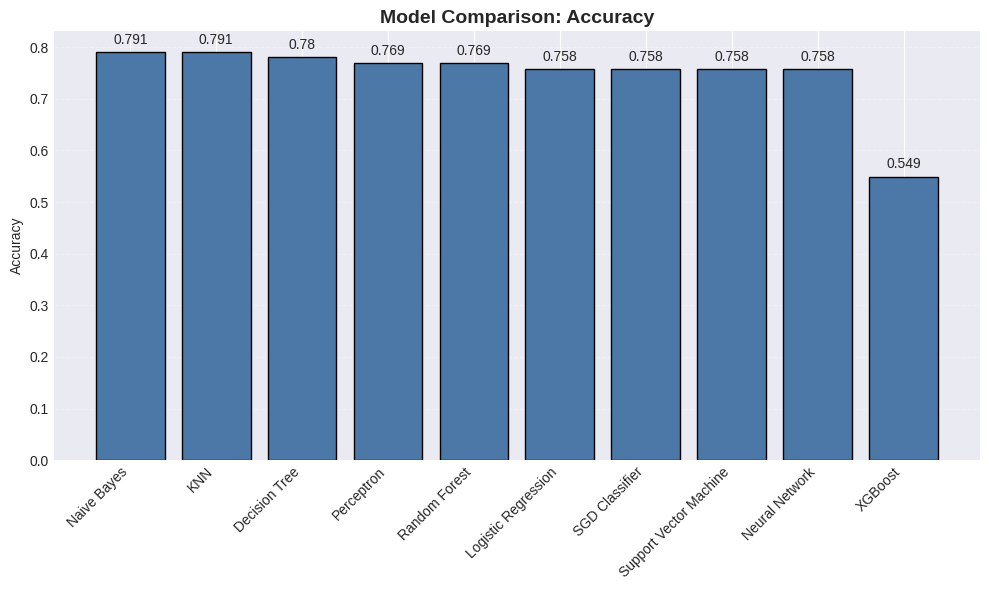

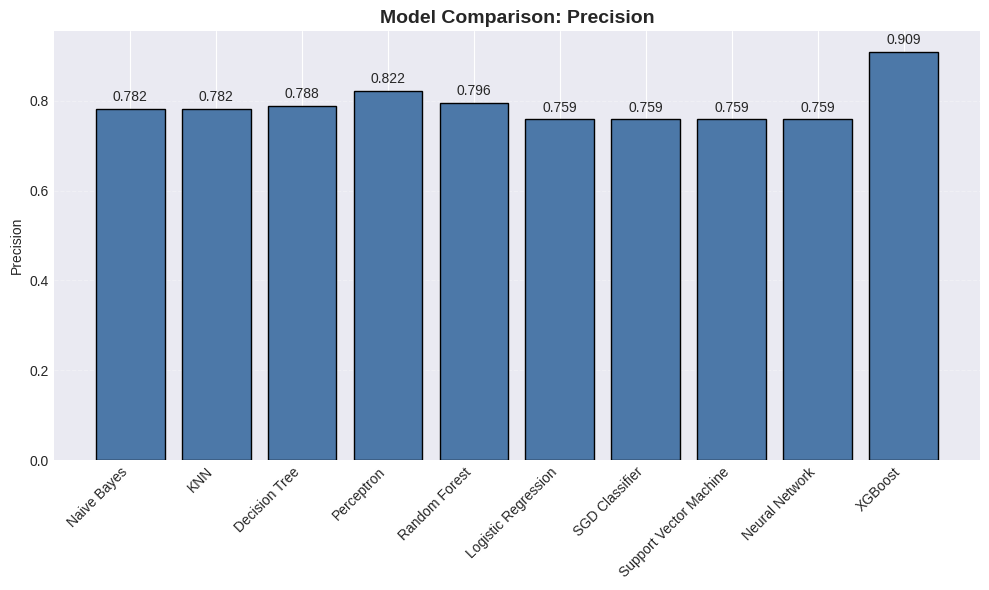

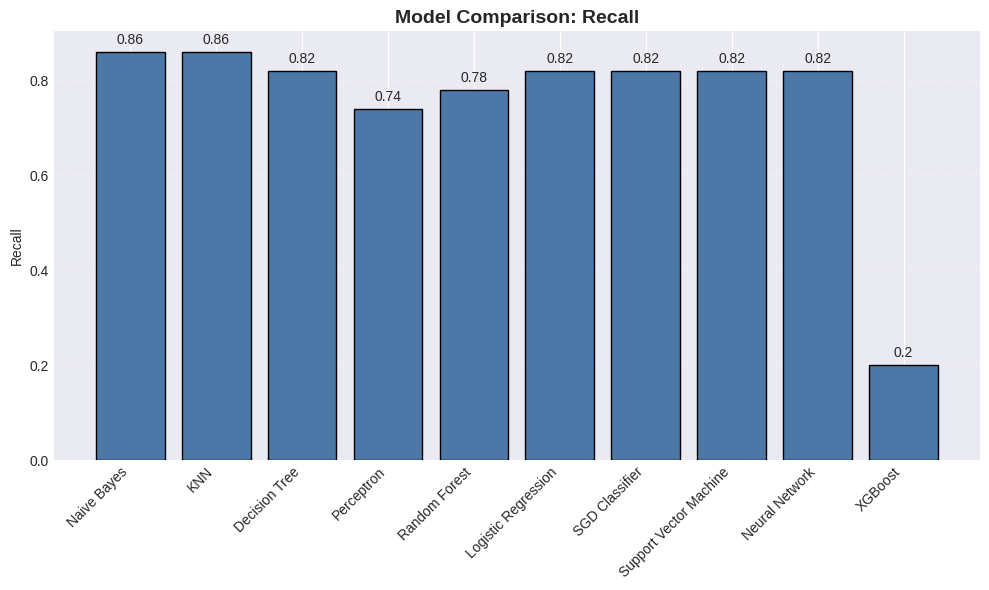

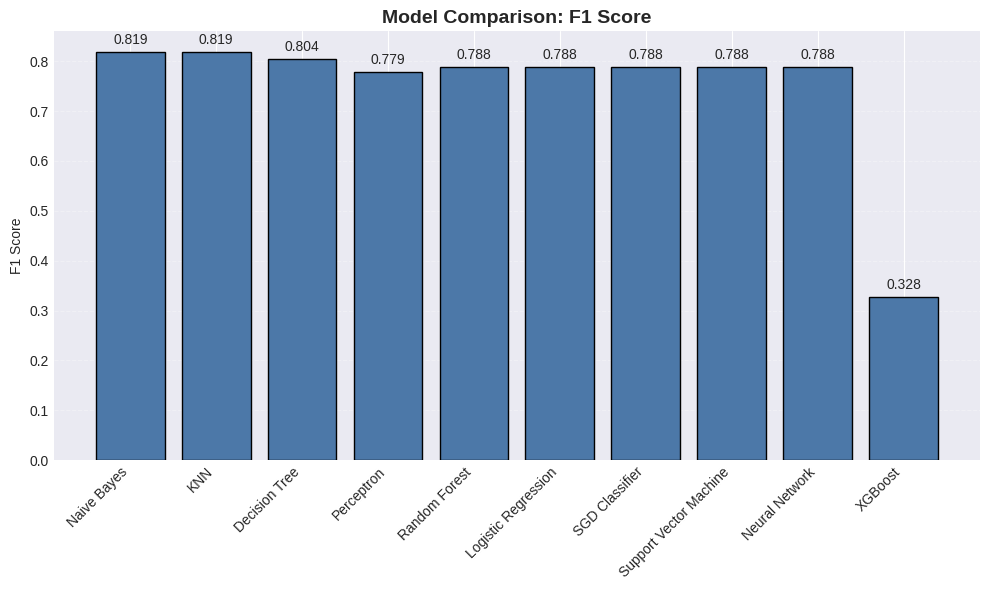

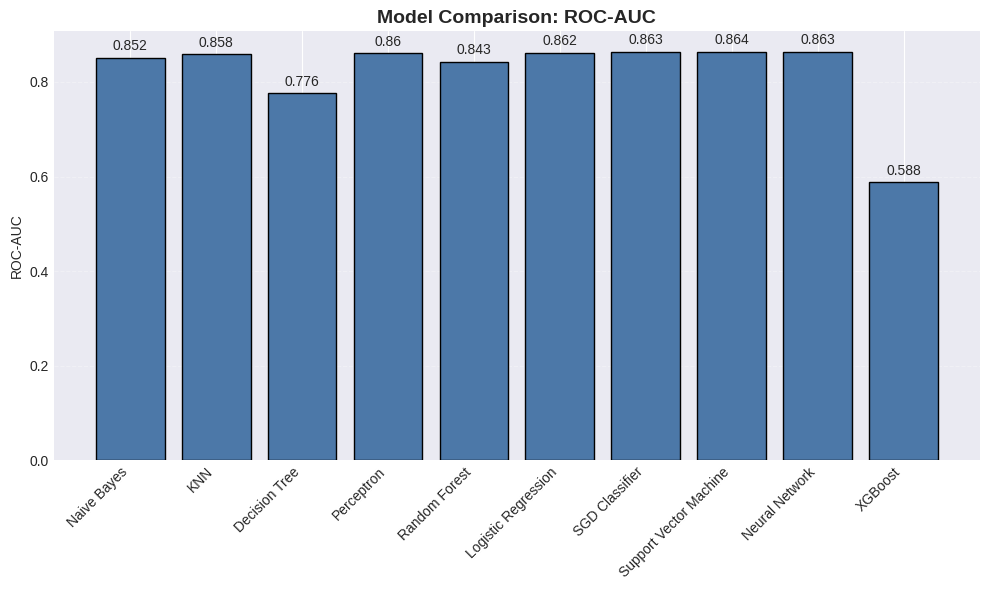

In [80]:
for metric in ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']:
    plt.figure(figsize=(10, 6))
    bars = plt.bar(comparison_df['Algorithm'], comparison_df[metric], color='#4c78a8', edgecolor='black')
    plt.title(f'Model Comparison: {metric}', fontsize=14, fontweight='bold')
    plt.ylabel(metric)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.01, round(height, 3), ha='center', va='bottom')
    plt.tight_layout()
    plt.show()

In [81]:
best_row = comparison_df.loc[comparison_df['Accuracy'].idxmax()]
print('Best model:', best_row['Algorithm'])
print('Highest accuracy:', round(best_row['Accuracy'], 4))
print('Highest F1 score:', round(best_row['F1 Score'], 4))
print('Highest ROC-AUC:', round(best_row['ROC-AUC'], 4))
print('Brief explanation: The best model performed well due to a good balance of bias and variance on the Heart Disease dataset.')

Best model: Naive Bayes
Highest accuracy: 0.7912
Highest F1 score: 0.819
Highest ROC-AUC: 0.8517
Brief explanation: The best model performed well due to a good balance of bias and variance on the Heart Disease dataset.
